# Housing model prediction

In this notebook, I will investigate machine learning model to **predict** the housing prince based on existing feaures and **aggregated** feaures. The models include Linear Regression (LR), Random Forest Regression (RF) and XGBoost model.

This notebook begins with loading and cleaning data. Once ready, the data is splited into train/test sets. The data is then scaled for LR model, while RF and XGBoost use the original data. I use these data to train the models, which are evaluated by $R^2$ score in Section II. The errors are conducted by the *residule analysis* in Section III.

To enhance the models, I aggregate the new features from the existing features in Secion IV, where all three models are considered with the residule analysis. Section V concludes this analysis.

In [113]:
import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt
import stat as sm
import scipy
from scipy import stats
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "Helvetica Neue"

# Table of Contents

I. [Data Cleaning](#i-data-cleaning)

II. Modelling from existing features
- IIA. [Linear Regression](#iia-linear-regression)
- IIB. [Random Forest Regression](#iib-random-forest-regression)
- IIC. [XGBoost Regression](#iic-xgboost-regression)

III. [Residual Analysis](#iii-residual-analysis)

IV. Modelling with aggregated features
- IVA. [Linear Regression](#iva-linear-regression)
- IVB. [Random Forest Regression](#ivb-random-forest-regression)
- IVC. [XGBoost Regression](#ivc-xgboost-regression)
- IVD. [Residual Analysis](#ivd-residual-analysis)

V. [Conclusion](#v-conclusion)

## Importing and cleansing data 

In this analysis, I use the data retrieved from https://www.kaggle.com/datasets/nalisha/california-housing-prices-dataset-clean-and-ml/data, which is California data.

In [28]:
#Importing the data.
data = pd.read_csv("housing.csv")
display(data.head())

print("-----Data Shape----\n")
print(data.shape)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


-----Data Shape----

(20640, 10)


Get some key statistical properties of the data.

In [29]:
print("\n-----Description-----\n")
display(data.describe())

print("\n----Information-----\n")
display(data.info())


-----Description-----



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



----Information-----

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


None

Notice, there are null data in "total_bedrooms".

As our goal is to predict the median_house_value, let us first check if the "median_house_value" has a good distribution.

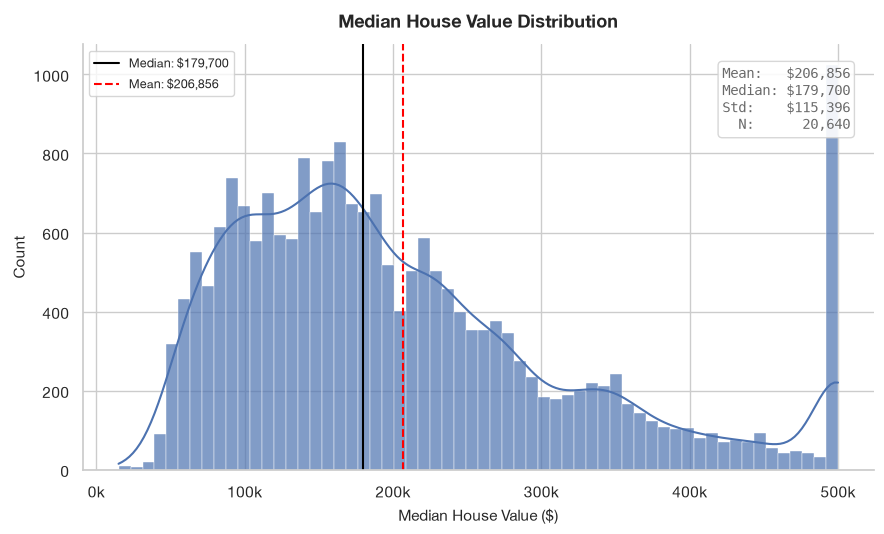

Median of Median House Value is 179700.0
Mean of Median House Value is 206855.81690891474
Standard deviation of Median House Value is 115395.61587441387


In [30]:
fig, ax = plt.subplots(figsize=(9, 5.5))

sns.histplot(
    data=data, x="median_house_value", bins=60, kde=True,
    ax=ax, color="#4C72B0", edgecolor="white", linewidth=0.3, alpha=0.7
)

median_val = data["median_house_value"].median()
mean_val = data["median_house_value"].mean()
std_val = data["median_house_value"].std()

ax.axvline(median_val, color="black", linestyle="-", linewidth=1.5, label=f"Median: ${median_val:,.0f}")
ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: ${mean_val:,.0f}")

ax.set_title("Median House Value Distribution", fontsize=13, weight="bold", pad=12)
ax.set_xlabel("Median House Value ($)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

stats_text = (
    f"Mean:   ${mean_val:,.0f}\n"
    f"Median: ${median_val:,.0f}\n"
    f"Std:    ${std_val:,.0f}\n"
    f"N:      {len(data):,}"
)
ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
        ha="right", va="top", fontsize=10, family="monospace", color="dimgray",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="lightgray", alpha=0.9))

ax.legend(loc="upper left", frameon=True, fontsize=9)
sns.despine()

plt.tight_layout()
plt.savefig("images/median_house_value_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Median of Median House Value is", median_val)
print("Mean of Median House Value is", mean_val)
print("Standard deviation of Median House Value is", std_val)

As the mean is greater than the median, the median house value shows a right-skewed distribution with a huge outlier around $500000. This outlier can cause bias in prediection and, importanly, the divergence of a model like LR. It should be filtered out. In the next step, I will clean the data before modelling.

# I. Data Cleaning and Preparing

As seen in the distribution above, I will filter out the outlier by keeping data up to 95th percentile.

In [31]:
data_cut = data["median_house_value"].quantile(0.95)
data_clean = data[data["median_house_value"] <= data_cut].copy()

As we know that there are null values in "total_bedrooms", I will replace the null values with its corresponding median in this analysis.

In [32]:
print("\n-----Before Missing Value------\n")
display(data_clean.isnull().sum())

data_clean["total_bedrooms"] = data_clean["total_bedrooms"].fillna(
    data_clean["total_bedrooms"].median()
)
print("\n-----After Missing Value------\n")
display(data_clean.isnull().sum())


-----Before Missing Value------



longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


-----After Missing Value------



longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Check again if the data makes sense now.

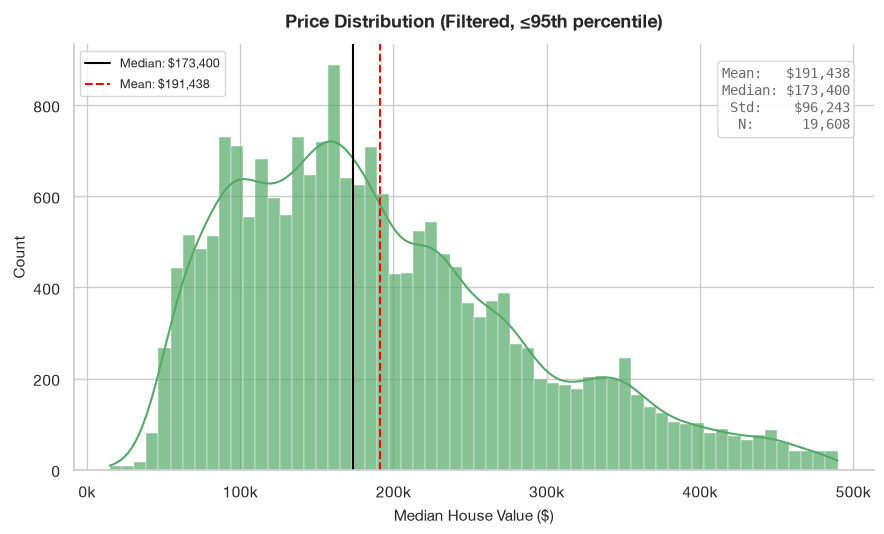

In [33]:
# Define the price and create feature dataframe
y = data_clean["median_house_value"]
features = data_clean.drop(["median_house_value"], axis =1)

# Plot the price distribution
fig, ax = plt.subplots(figsize=(9, 5.5))

sns.histplot(
    y, bins=60, kde=True,
    ax=ax, color="#55A868", edgecolor="white", linewidth=0.3, alpha=0.7
)

median_val = y.median()
mean_val = y.mean()
std_val = y.std()

ax.axvline(median_val, color="black", linestyle="-", linewidth=1.5, label=f"Median: ${median_val:,.0f}")
ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: ${mean_val:,.0f}")

ax.set_title("Price Distribution (Filtered, ≤95th percentile)", fontsize=13, weight="bold", pad=12)
ax.set_xlabel("Median House Value ($)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

stats_text = (
    f"Mean:   ${mean_val:,.0f}\n"
    f"Median: ${median_val:,.0f}\n"
    f"Std:    ${std_val:,.0f}\n"
    f"N:      {len(y):,}"
)
ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
        ha="right", va="top", fontsize=10, family="monospace", color="dimgray",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="lightgray", alpha=0.9))

ax.legend(loc="upper left", frameon=True, fontsize=9)
sns.despine()

plt.tight_layout()
plt.savefig("images/median_house_value_distribution_filtered.png", dpi=300, bbox_inches="tight")
plt.show()

The numbers of rows are now with 19,608, where the price distribution is still right-skewed but the big outliers have been filtered out.

Next, I want to translate the ocean proximity category to numerical integers. But first, we want to check how many unique values are there for ocean category column.

In [34]:
features["ocean_proximity"].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

As there are 5 categories in this, we can index them as follows.

In [35]:
features_num = pd.get_dummies(features, columns=["ocean_proximity"], drop_first=True, dtype=int)
features_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,1,0


Note, that the missing one is "less than 1H from ocean" (the most freuqnect one dropped first).

## Spliting and Scaling

To buit the learning model, I now want to:

First, I want to split the data into training set and testing set (70:30 in for my model). This way, I can produce the models via the training set and test them with the testing set.

Second, for faster convergence, I want to rescale the data. I this model, I choose the StandarScaler (respect to its mean and standard deviation). Only the continuous data are scaled while the categorical data remains unscaled.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(features_num, y, test_size=0.3, random_state=42)

## Scalling data
continuous_cols = ["longitude", "latitude", "housing_median_age", "total_rooms",
                    "total_bedrooms", "population", "households", "median_income"]
dummy_cols = ["ocean_proximity_INLAND", "ocean_proximity_ISLAND",
              "ocean_proximity_NEAR BAY", "ocean_proximity_NEAR OCEAN"]

# Continuous columns
X_scaler = StandardScaler()
X_train_cont = X_scaler.fit_transform(X_train[continuous_cols])  
X_test_cont = X_scaler.transform(X_test[continuous_cols]) 

# Combining discrete data
X_train_norm = np.hstack([X_train_cont, X_train[dummy_cols].values])
X_test_norm = np.hstack([X_test_cont, X_test[dummy_cols].values])

# II. Modelling from existing features

## IIA. Linear Regressino Model

In [37]:
sgdr = SGDRegressor(max_iter=2000, random_state=42)
sgdr.fit(X_train_norm, y_train)
y_pred_sgd = sgdr.predict(X_test_norm)
print("R2 score is", r2_score(y_test, y_pred_sgd))
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")
print(f"Converged: {sgdr.n_iter_ < sgdr.max_iter}")

R2 score is 0.6041286437152336
SGDRegressor(max_iter=2000, random_state=42)
number of iterations completed: 21, number of weight updates: 288226.0
Converged: True


The linear regression model only gives 60% of the R2 score. Unsuprisingly, this is because the nature of the data itself is *non-linear*.

We can check the weighted parameters here.

In [38]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")

model parameters:                   w: [-46598.54247924 -47079.16912754  10279.45001546 -14989.47147888
  27013.83207806 -35129.00275898  24753.96980558  58957.06042716
 -39169.33950085   6134.77075127  -8070.01908195   5061.2716876 ], b:[205650.85625925]


The coefficients reveal that "median_income" has the highest weight to this model with 58957.06042716.

We can plot the predicted values vs the y_test. A pefect prediction should follow a linear y=x curve.

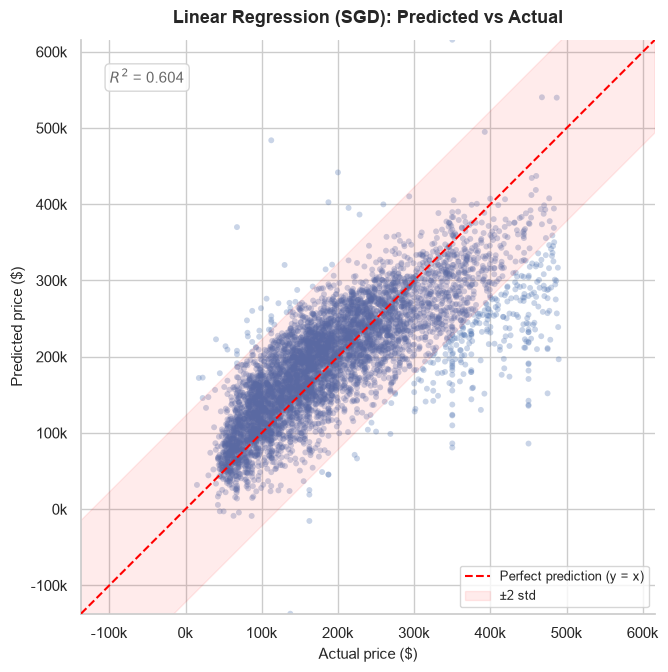

In [126]:
sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(7, 7))

sns.scatterplot(
    x=y_test, y=y_pred_sgd, ax=ax,
    alpha=0.3, s=18, color="#4C72B0", edgecolor="none"
)

# perfect-prediction reference line
lims = [min(y_test.min(), y_pred_sgd.min()), max(y_test.max(), y_pred_sgd.max())]
ax.plot(lims, lims, color="red", linestyle="--", linewidth=1.5, label="Perfect prediction (y = x)", zorder=3)

# ±2 std error envelope around the y = x line
residuals = y_test - y_pred_sgd
resid_std = residuals.std()

x_line = np.linspace(lims[0], lims[1], 200)

ax.fill_between(
    x_line, x_line - 2 * resid_std, x_line + 2 * resid_std,
    color="red", alpha=0.08, label="±2 std", zorder=1
)

r2 = r2_score(y_test, y_pred_sgd)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("Actual price ($)", fontsize=11)
ax.set_ylabel("Predicted price ($)", fontsize=11)
ax.set_title("Linear Regression (SGD): Predicted vs Actual", fontsize=13, weight="bold", pad=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes,
        ha="left", va="top", fontsize=11, color="dimgray",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="lightgray", alpha=0.9))
ax.legend(loc="lower right", frameon=True, fontsize=9)
sns.despine()

fig.subplots_adjust(left=0.12, right=0.95, top=0.92, bottom=0.1)
plt.savefig("images/sgd_predicted_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

In [127]:
print("Residual mean:", residuals.mean())
print("Residual std:", resid_std)
print("Skew:", stats.skew(residuals))
print("% within ±2 std:", ((residuals.abs() <= 2*residuals.std())).mean() * 100)

Residual mean: -919.7580935182716
Residual std: 61136.3984228657
Skew: 1.0192833631344955
% within ±2 std: 94.78157402685704


Notice that, the model can handle well for small price while some deviations from the higher price from the linear curve. Note that the shaded area represents 94.8% of data, where the standard deviation of the residules is $61136.4. We shall see the residule analysis in later section.

## IIB. Random Forest model

In this analysis, the next model is Random forest model. The reason for this is that it can handle non-linear natures of the data very well. By randomly grouping data into numbers of trees, each tree will make a prediction of the price. The final prediction result is given by the average of all trees. 

For each tree, the data is split at decision nodes, where the splitting feature is randomly chosen from a subset of sqrt(N) features. In our case, there are 12 features in total, such as latitude and longitude. Each decision node asks a simple yes or no question based on a threshold, for example "is median_income > 3.5?". This splitting process continues until it reaches the maximum depth, or until a node has too few samples to split further, which is controlled by the minimum samples split parameter. Once a branch can no longer split, it becomes a leaf, and the prediction at that leaf is simply the average price of all training rows that ended up there.

The final prediction for any new data point is the average of the leaf predictions across all trees.

Here, I choose the model with 200 trees. 

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=40)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(r2_score(y_test, y_pred_rf)) 

0.7832198623640093


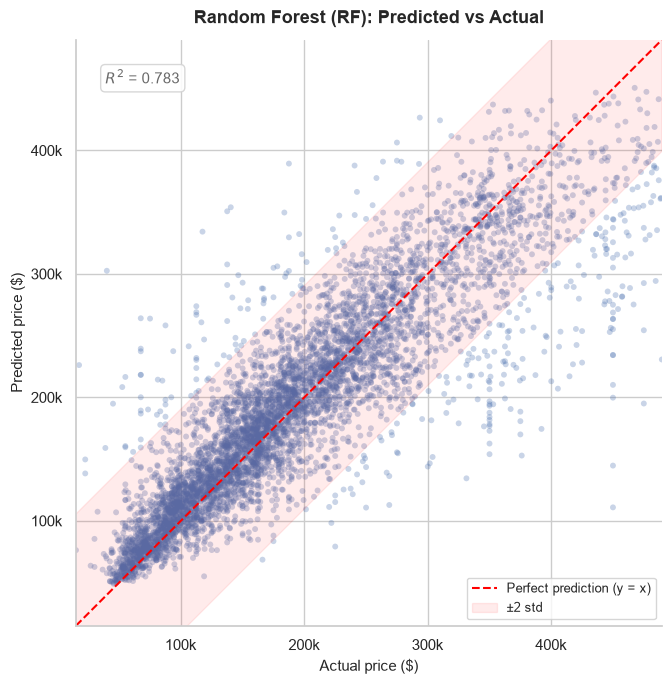

In [132]:
# Plot actual price vs prediction
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(7, 7))

sns.scatterplot(
    x=y_test, y=y_pred_rf, ax=ax,
    alpha=0.3, s=18, color="#4C72B0", edgecolor="none"
)

# perfect-prediction reference line
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
ax.plot(lims, lims, color="red", linestyle="--", linewidth=1.5, label="Perfect prediction (y = x)")

# ±2 std error envelope around the y = x line
residuals = y_test - y_pred_rf
resid_rf = residuals.std()

x_line = np.linspace(lims[0], lims[1], 200)

ax.fill_between(
    x_line, x_line - 2 * resid_rf, x_line + 2 * resid_rf,
    color="red", alpha=0.08, label="±2 std", zorder=1
)

r2 = r2_score(y_test, y_pred_rf)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("Actual price ($)", fontsize=11)
ax.set_ylabel("Predicted price ($)", fontsize=11)
ax.set_title("Random Forest (RF): Predicted vs Actual", fontsize=13, weight="bold", pad=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes,
        ha="left", va="top", fontsize=11, color="dimgray",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="lightgray", alpha=0.9))

ax.legend(loc="lower right", frameon=True, fontsize=9)
sns.despine()

plt.tight_layout()
plt.savefig("images/RF_predicted_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

In [129]:
print("Residual mean:", residuals.mean())
print("Residual std:", resid_rf)
print("Skew:", stats.skew(residuals))
print("% within ±2 std:", ((residuals.abs() <= 2*residuals.std())).mean() * 100)

Residual mean: -758.1570627231005
Residual std: 45239.8042763802
Skew: 0.9235270880690594
% within ±2 std: 94.32262451130376


Clearly, the $R^2$ score is much improved compared to the linear regression model. However, some outliers are seen in extreme small and high prices. The shaded area represents 94.3% of data, where the standard deviation of the residules is now smaller than the LR model with $45239.8.

We can also further optimise the models as follow.


### Opitimised Random Forest method

Here, I choose to optimise this model with respect to the number of trees, maximum depth, and minimum samples split. This can be done using GridSearchCV, which tries every possible combination of parameters. However, since this can be quite slow for a large parameter grid, I used RandomizedSearchCV instead, which samples a fixed number of random combinations and finds a good configuration much faster.

In [42]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10]
}

rf_base = RandomForestRegressor(random_state=40)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=24,          # only tries 20 random combinations instead of all 48
    cv=5, # 5-fold cross validation
    scoring="r2", # optimise for R2
    n_jobs=-1, # use all CPU cores to speed it up
    random_state=40 
)

random_search.fit(X_train, y_train)

print("\n-----Report------\n")
print("Best parameters:", random_search.best_params_)

## Extracting the best configuration.
best_rf = random_search.best_estimator_

y_rf_tuned = best_rf.predict(X_test)
print("Test R2:", r2_score(y_test, y_rf_tuned))

/Users/s2987959/miniforge3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



-----Report------

Best parameters: {'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 30}
Test R2: 0.7844279671969743


#### Model insights

The best model is only **slightly** better $R^3$ score than the "naive" model.

Now, let's look into the Random Forest model and how each feature contributes to the model via Feature importance. The feature importance tells you that which feature gives the error reduction the most (mean square error in this model). That is, it tells you what data you should be looking at to make a well prediction.

                       Feature  Importance
7                median_income    0.440166
8       ocean_proximity_INLAND    0.159513
0                    longitude    0.119896
1                     latitude    0.114215
2           housing_median_age    0.046602
5                   population    0.034770
3                  total_rooms    0.028470
4               total_bedrooms    0.023558
6                   households    0.021093
11  ocean_proximity_NEAR OCEAN    0.010459
10    ocean_proximity_NEAR BAY    0.000968
9       ocean_proximity_ISLAND    0.000291


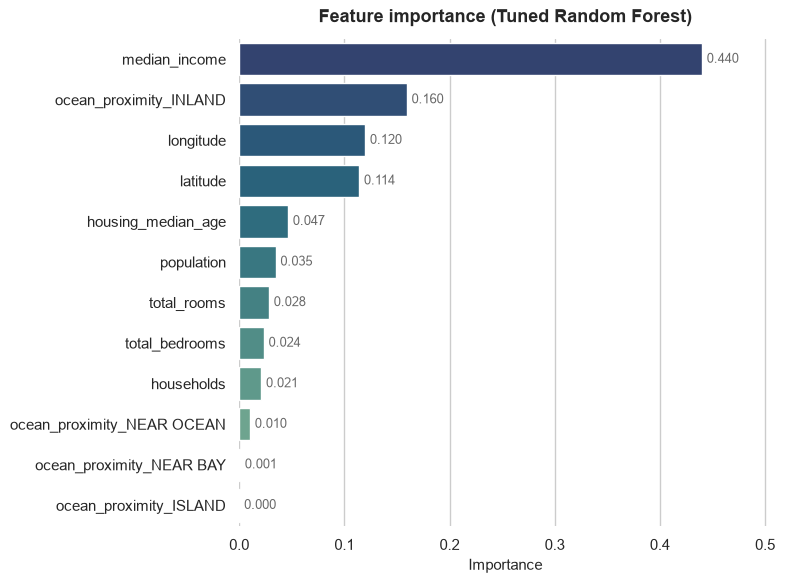

In [43]:
importances = best_rf.feature_importances_
feature_names = X_train.columns


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df)

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette("crest", n_colors=len(importance_df))[::-1]

# Plotting
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette=palette,
    legend=False,
    ax=ax
)

# annotate each bar with its value
for i, v in enumerate(importance_df["Importance"]):
    ax.text(v + importance_df["Importance"].max() * 0.01, i, f"{v:.3f}",
            va="center", fontsize=9, color="dimgray")

ax.set_xlabel("Importance", fontsize=11)
ax.set_ylabel("")
ax.set_title("Feature importance (Tuned Random Forest)", fontsize=13, weight="bold", pad=12)
ax.set_xlim(0, importance_df["Importance"].max() * 1.15)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

That is the median income highly contributes to the accurate model. Note that there may be biases towards unique features like ocean proximity as these are registered only 0 and 1.

## IIC. XGBoost model

The last model in this analysis is XGBoost. Instead of splitting independent trees as the Random Forest model does, XGBoost builds trees sequentially, with each new tree correcting the errors of the previous ones, gradually minimising the price error. Given this, it is more powerful than the RF model, at the cost of being more computationally expensive.

In this model, I choose parameters as follows.

In [44]:
from xgboost import XGBRegressor

xgbr = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)
xgbr.fit(X_train, y_train)
y_pred_xgb = xgbr.predict(X_test)
print("R2 score is", r2_score(y_test, y_pred_xgb))

R2 score is 0.8016744282148054


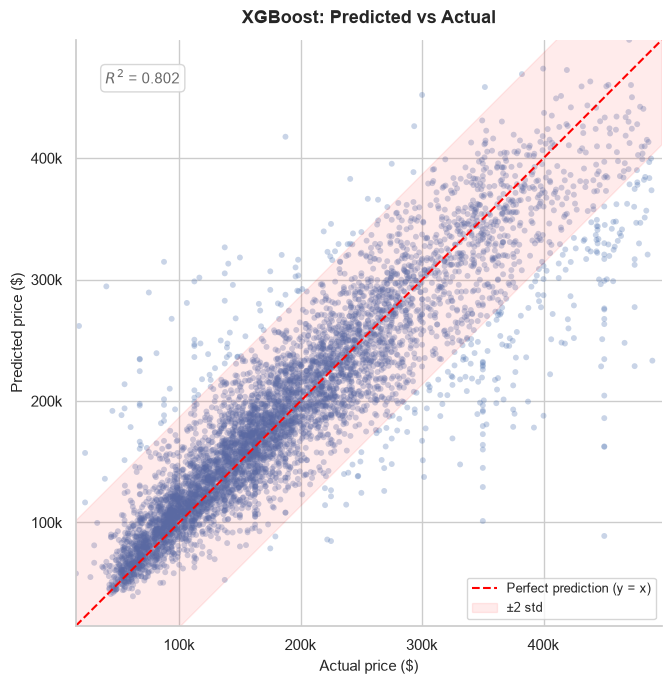

In [130]:
# Plot actual price vs prediction
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(7, 7))

sns.scatterplot(
    x=y_test, y=y_pred_xgb, ax=ax,
    alpha=0.3, s=18, color="#4C72B0", edgecolor="none"
)

# perfect-prediction reference line
lims = [min(y_test.min(), y_pred_xgb.min()), max(y_test.max(), y_pred_xgb.max())]
ax.plot(lims, lims, color="red", linestyle="--", linewidth=1.5, label="Perfect prediction (y = x)")

# ±2 std error envelope around the y = x line
residuals =  y_test-y_pred_xgb
resid_xgb = residuals.std()

x_line = np.linspace(lims[0], lims[1], 200)

ax.fill_between(
    x_line, x_line - 2 * resid_xgb, x_line + 2 * resid_xgb,
    color="red", alpha=0.08, label="±2 std", zorder=1
)

r2 = r2_score(y_test, y_pred_xgb)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("Actual price ($)", fontsize=11)
ax.set_ylabel("Predicted price ($)", fontsize=11)
ax.set_title("XGBoost: Predicted vs Actual", fontsize=13, weight="bold", pad=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes,
        ha="left", va="top", fontsize=11, color="dimgray",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="lightgray", alpha=0.9))

ax.legend(loc="lower right", frameon=True, fontsize=9)
sns.despine()

plt.tight_layout()
plt.savefig("images/xgb_predicted_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

In [131]:
print("Residual mean:", residuals.mean())
print("Residual std:", resid_xgb)
print("Skew:", stats.skew(residuals))
print("% within ±2 std:", ((residuals.abs() <= 2*residuals.std())).mean() * 100)

Residual mean: -216.81727076427842
Residual std: 43276.872473370146
Skew: 0.9191273027409453
% within ±2 std: 94.40761516233215


The $R^2$ score is now reached 80%, improving from the RF model. Aslo the shaded area represents 94.4% of data, where the standard deviation of the residules is now improved to than the LR model with $43276.9.

It is still seen that the higher price is pretty hard to model correctly.

### Model insight

                       Feature  Importance
8       ocean_proximity_INLAND    0.569722
7                median_income    0.169348
9       ocean_proximity_ISLAND    0.050552
11  ocean_proximity_NEAR OCEAN    0.045285
1                     latitude    0.031598
0                    longitude    0.030231
10    ocean_proximity_NEAR BAY    0.025821
5                   population    0.019961
2           housing_median_age    0.018462
4               total_bedrooms    0.014773
6                   households    0.013374
3                  total_rooms    0.010872


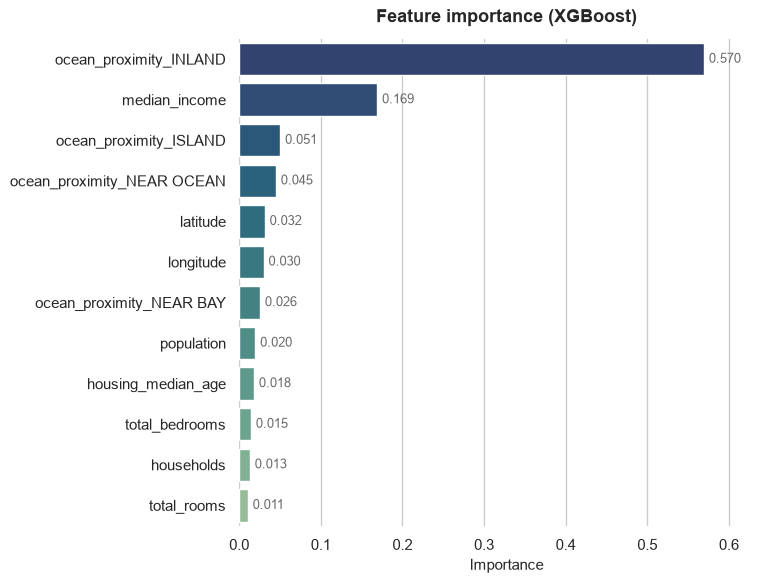

In [46]:
importances = xgbr.feature_importances_
feature_names = X_train.columns


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df)

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette("crest", n_colors=len(importance_df))[::-1]

# Plotting
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette=palette,
    legend=False,
    ax=ax
)

# annotate each bar with its value
for i, v in enumerate(importance_df["Importance"]):
    ax.text(v + importance_df["Importance"].max() * 0.01, i, f"{v:.3f}",
            va="center", fontsize=9, color="dimgray")

ax.set_xlabel("Importance", fontsize=11)
ax.set_ylabel("")
ax.set_title("Feature importance (XGBoost)", fontsize=13, weight="bold", pad=12)
ax.set_xlim(0, importance_df["Importance"].max() * 1.15)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("images/feature_importance_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

Interestlingly, the feauture importance reveals that "ocean_prodimity_inland" is the cheif contribution as oppose to what I found in the RF model. RF model cannot uncover this features.

# III. Residual Analysis

In this step, we want to look at the errors genrated by each model to analyse how relailable they are. 

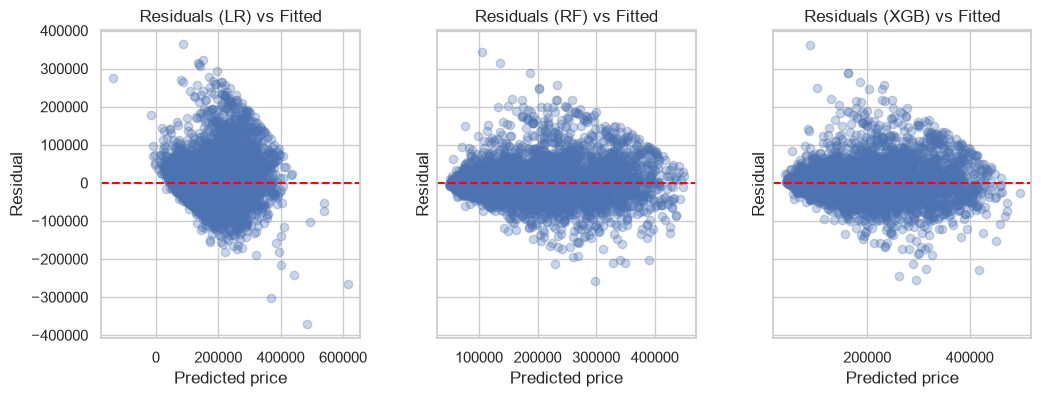

In [133]:
residuals_LR = y_test - y_pred_sgd # Linear regression model
residuals_RF = y_test - y_rf_tuned # Tuned random forest model
residuals_XG = y_test - y_pred_xgb # XGBoost

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
plt.subplots_adjust(wspace=0.3)

ax[0].scatter(y_pred_sgd, residuals_LR, alpha=0.3)
ax[0].set_xlabel("Predicted price")
ax[0].set_ylabel("Residual")
ax[0].set_title("Residuals (LR) vs Fitted")
ax[0].axhline(0, color='red', linestyle='--')

ax[1].scatter(y_rf_tuned, residuals_RF, alpha=0.3)
ax[1].set_xlabel("Predicted price")
ax[1].set_ylabel("Residual")
ax[1].set_title("Residuals (RF) vs Fitted")
ax[1].axhline(0, color='red', linestyle='--')

ax[2].scatter(y_pred_xgb, residuals_XG, alpha=0.3)
ax[2].set_xlabel("Predicted price")
ax[2].set_ylabel("Residual")
ax[2].set_title("Residuals (XGB) vs Fitted")
ax[2].axhline(0, color='red', linestyle='--')

plt.savefig("images/residuals_vs_fitted.png", dpi=300)
plt.show()

A perfect model should give zero residuals. We see that all models cannot handle weel at extreme prices (small and big), where LR tends to produce bigger errors than the other two.

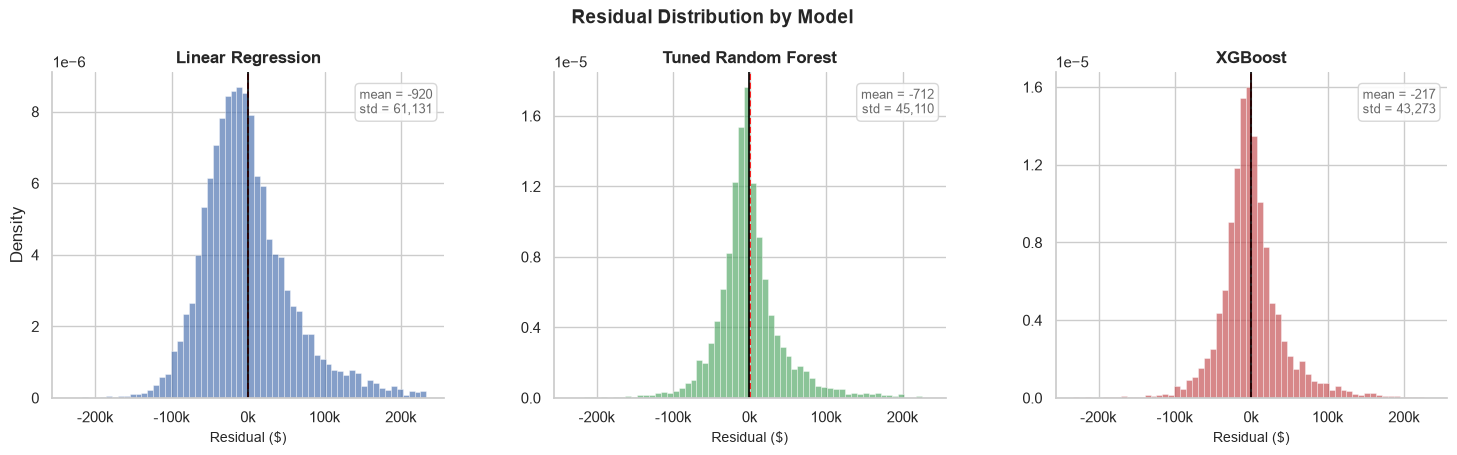

Mean residual (LR): -919.8
Std of residuals (LR): 61131.2
Mean residual (RF): -711.9
Std of residuals (RF): 45110.5
Mean residual (XG): -216.8
Std of residuals (XG): 43273.2


In [134]:
import os

sns.set_theme(style="whitegrid", context="notebook")
os.makedirs("images", exist_ok=True)
plt.close("all")

datasets_raw = [
    (residuals_LR, "Linear Regression", "#4C72B0"),
    (residuals_RF, "Tuned Random Forest", "#55A868"),
    (residuals_XG, "XGBoost", "#C44E52"),
]

datasets = []
for resid, label, color in datasets_raw:
    resid = np.asarray(resid, dtype="float64").ravel()
    resid = resid[np.isfinite(resid)]
    datasets.append((resid, label, color))

# Use a central range so the plot does not get crushed by extreme residuals
x_limit = max(np.percentile(np.abs(resid), 99.5) for resid, _, _ in datasets)
bins = np.linspace(-x_limit, x_limit, 61)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), sharey=False)

for i, (resid, label, color) in enumerate(datasets):
    plot_resid = resid[(resid >= -x_limit) & (resid <= x_limit)]

    ax[i].hist(
        plot_resid,
        bins=bins,
        density=True,
        color=color,
        alpha=0.68,
        edgecolor="white",
        linewidth=0.4
    )

    mean_r = resid.mean()
    std_r = resid.std()

    ax[i].axvline(0, color="red", linestyle="--", linewidth=1.2)
    ax[i].axvline(mean_r, color="black", linestyle="-", linewidth=1.2)

    ax[i].set_title(label, fontsize=12, weight="bold")
    ax[i].set_xlabel("Residual ($)", fontsize=10)
    ax[i].set_ylabel("Density" if i == 0 else "")

    ax[i].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")
    )
    ax[i].yaxis.set_major_locator(mticker.MaxNLocator(5))

    stats_text = (
        f"mean = {mean_r:,.0f}\n"
        f"std = {std_r:,.0f}"
    )

    ax[i].text(
        0.97,
        0.95,
        stats_text,
        transform=ax[i].transAxes,
        ha="right",
        va="top",
        fontsize=9,
        color="dimgray",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.9
        )
    )

    sns.despine(ax=ax[i])

fig.suptitle("Residual Distribution by Model", fontsize=14, weight="bold", y=0.97)
fig.subplots_adjust(left=0.06, right=0.99, bottom=0.16, top=0.84, wspace=0.28)

fig.savefig("images/residual_distribution.png", dpi=300)
plt.show()

for name, resid in [("LR", residuals_LR), ("RF", residuals_RF), ("XG", residuals_XG)]:
    resid = np.asarray(resid, dtype="float64").ravel()
    resid = resid[np.isfinite(resid)]

    print(f"Mean residual ({name}): {resid.mean():.1f}")
    print(f"Std of residuals ({name}): {resid.std():.1f}")

Both have their resuduals with a "normal" distribution and centered at zero. In general, XGBoost produces the smallest error with the mean of - \\$217 and std of \\$43,273, followed by Tuned RF model with the mean of -\\$712 with a biger std of \\$45110. The LR model gives an aveage error of -\$920 with the higest std of \\$61,136. Note that, I use the tuned Random forest in this error analysis.


Let's also see top 15th worst prediction to see if we can aggregate any feature.

In [87]:
error_df = X_test.copy()
error_df["actual"] = y_test.values

## Linear regression model
error_df["predicted_LR"] = y_pred_sgd
error_df["abs_error_LR"] = np.abs(residuals_LR.values)

## Tuned Random forest
error_df["predicted_RF"] = y_rf_tuned
error_df["abs_error_RF"] = np.abs(residuals_RF.values)

## XGBoost
error_df["predicted_XG"] = y_pred_xgb
error_df["abs_error_XG"] = np.abs(residuals_XG.values)

print("-----Worst prediction (LR)----\n")
print(error_df.sort_values("abs_error_LR", ascending=False).head(5))

print("-----Worst prediction (RF)----\n")
print(error_df.sort_values("abs_error_RF", ascending=False).head(5))

print("-----Worst prediction (XGB)----\n")
print(error_df.sort_values("abs_error_XG", ascending=False).head(5))

-----Worst prediction (LR)----

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
11912    -117.44     33.96                29.0        124.0            22.0   
19542    -120.92     37.63                39.0         45.0             8.0   
1633     -122.22     37.88                20.0         95.0            13.0   
10616    -117.81     33.69                 5.0       1256.0           256.0   
15635    -122.41     37.80                30.0       1821.0           738.0   

       population  households  median_income  ocean_proximity_INLAND  \
11912        50.0        18.0        12.5381                       1   
19542        22.0         9.0         1.7679                       1   
1633         31.0        15.0         2.4444                       0   
10616       880.0       288.0         2.4233                       0   
15635      1648.0       684.0         0.8836                       0   

       ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
1

#### Errors by map

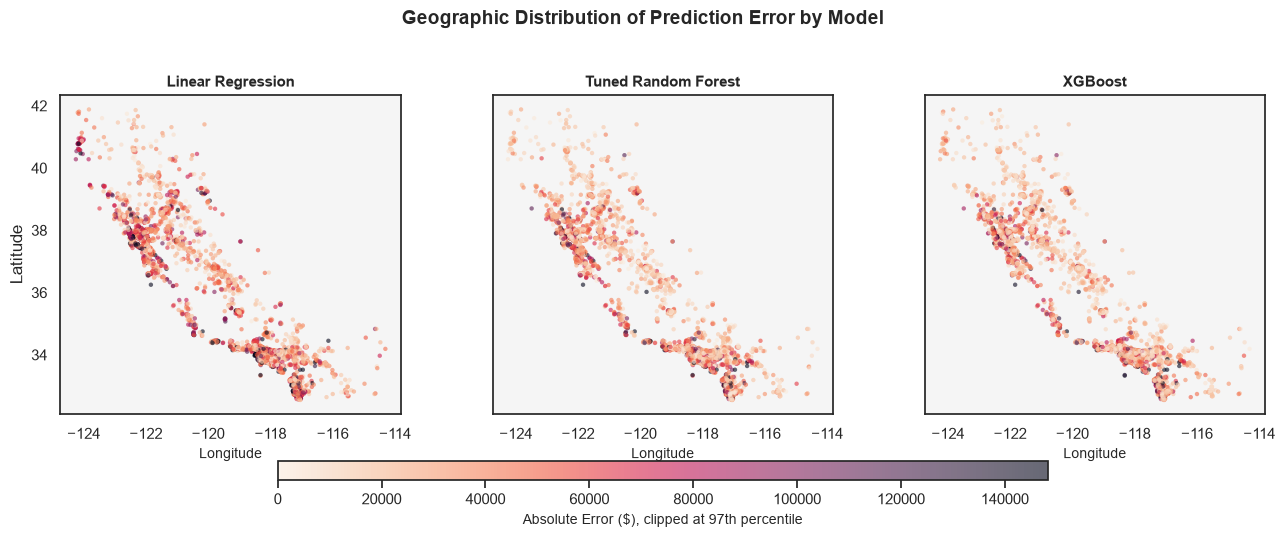

In [88]:
sns.set_theme(style="white", context="notebook")

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
plt.subplots_adjust(wspace=0.15)

cols = ["abs_error_LR", "abs_error_RF", "abs_error_XG"]
labels = ["Linear Regression", "Tuned Random Forest", "XGBoost"]

# shared color scale across all 3 panels, robust to a few extreme outlier errors
vmin = 0
vmax = error_df[cols].quantile(0.97).max()

for i, (col, label) in enumerate(zip(cols, labels)):
    sc = ax[i].scatter(
        error_df["longitude"], error_df["latitude"],
        c=error_df[col], cmap="rocket_r", alpha=0.6, s=10,
        vmin=vmin, vmax=vmax, edgecolor="none"
    )
    ax[i].set_title(f"{label}", fontsize=11, weight="bold")
    ax[i].set_xlabel("Longitude", fontsize=10)
    ax[i].set_ylabel("Latitude" if i == 0 else "")
    ax[i].set_aspect("equal")
    ax[i].set_facecolor("#f5f5f5")
    if i != 0:
        ax[i].set_yticklabels([])

# one shared colorbar instead of three separate ones
cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.05, pad=0.12, aspect=40)
cbar.set_label("Absolute Error ($), clipped at 97th percentile", fontsize=10)

fig.suptitle("Geographic Distribution of Prediction Error by Model", fontsize=14, weight="bold", y=1.05)

plt.savefig("images/error_map.png", dpi=300, bbox_inches="tight")
plt.show()

It is clear that geography matters. Big cities and cities long the coastaline shoul be considered.

# IV. Modelling with aggregated features

Let us consider rooms per houshold, bedrrods per rooms and population per household. Note that, since they are a ratio, I will take log of the new data to reduce skewness. 

In [89]:
# Aggrgate data. Note that I take Log to reduce the skewness of the data
X_agg = features_num
X_agg["rooms_per_household"] = np.log(X_agg["total_rooms"] / X_agg["households"])
X_agg["bedrooms_per_room"] = np.log(X_agg["total_bedrooms"] / X_agg["total_rooms"])
X_agg["population_per_household"] = np.log(X_agg["population"] / X_agg["households"])
X_agg["income_x_density"] = np.log(X_agg["median_income"] * (X_agg["population"] / X_agg["total_rooms"]))

# Distance to San Francisco
X_agg["dist_sf"] = np.sqrt((X_agg["latitude"] - 37.77)**2 + (X_agg["longitude"] - (-122.42))**2)
# Distance to Los Angeles
X_agg["dist_la"] = np.sqrt((X_agg["latitude"] - 34.05)**2 + (X_agg["longitude"] - (-118.24))**2)
# Distance to San Diego
X_agg["dist_sd"] = np.sqrt((X_agg["latitude"] - 32.72)**2 + (X_agg["longitude"] - (-117.15))**2)

# Distance to the nearest coastaline
from scipy.spatial import cKDTree

# Use rows already labeled as coastal (by ocean_proximity) as reference points
coastal_mask = data_clean["ocean_proximity"].isin(["NEAR BAY", "NEAR OCEAN"]) # set the reference points
coastal_points = data_clean.loc[coastal_mask, ["longitude", "latitude"]].values

# Build a KD-tree for fast nearest-neighbor lookup
tree = cKDTree(coastal_points)

# Query nearest coastal point for every row
all_points = data_clean[["longitude", "latitude"]].values
dist_deg, _ = tree.query(all_points, k=1)

# Convert degrees to km (1 degree latitude ≈ 111 km; rough but fine at California's scale)
X_agg["dist_coast_km"] = dist_deg * 111.0

display(X_agg.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household,income_x_density,dist_sf,dist_la,dist_sd,dist_coast_km
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,1,0,1.943640,-1.920110,0.938270,1.113917,0.219545,5.530732,7.240994,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,1,0,1.830682,-1.859204,0.746613,1.032356,0.219317,5.509673,7.219730,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,1,0,2.114825,-2.043951,1.030426,0.897623,0.196977,5.517246,7.226687,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,1,0,1.760845,-1.690331,0.935287,0.904876,0.187883,5.524500,7.233733,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,1,0,1.837665,-1.759704,0.779998,0.289418,0.187883,5.524500,7.233733,0.0


### Splitting aggregated data

In [90]:
#Spliting and scaling
X_train_agg, X_test_agg, y_train_agg, y_test_agg = train_test_split(X_agg, y, test_size=0.3, random_state=42)

## Scalling data
continuous_cols = ["longitude", "latitude", "housing_median_age", "total_rooms",
                    "total_bedrooms", "population", "households", "median_income"]
dummy_cols = ["ocean_proximity_INLAND", "ocean_proximity_ISLAND",
              "ocean_proximity_NEAR BAY", "ocean_proximity_NEAR OCEAN"]
# Continuous columns
X_scaler_agg = StandardScaler()
X_train_cont_agg = X_scaler_agg.fit_transform(X_train_agg[continuous_cols])  
X_test_cont_agg = X_scaler_agg.transform(X_test_agg[continuous_cols]) 

# Combining discrete data
X_train_norm_agg = np.hstack([X_train_cont_agg, X_train_agg[dummy_cols].values])
X_test_norm_agg = np.hstack([X_test_cont_agg, X_test_agg[dummy_cols].values])

## IVA. Linear regression model

In [91]:
#Linear regression
sgdr_agg = SGDRegressor(max_iter=2000)
sgdr_agg.fit(X_train_norm_agg, y_train_agg)
print(sgdr_agg)
print(f"number of iterations completed: {sgdr_agg.n_iter_}, number of weight updates: {sgdr_agg.t_}")
print(f"Converged: {sgdr_agg.n_iter_ < sgdr_agg.max_iter}")

# make a prediction using sgdr.predict()
y_pred_sgd_agg = sgdr_agg.predict(X_test_norm_agg)

# R2 score
r2_score(y_test_agg, y_pred_sgd_agg)

# Better to be explicit so it prints anywhere
print(f"Linear Regression R2 (with aggregated features): {r2_score(y_test_agg, y_pred_sgd_agg):.6f}")

SGDRegressor(max_iter=2000)
number of iterations completed: 18, number of weight updates: 247051.0
Converged: True
Linear Regression R2 (with aggregated features): 0.604717


By aggregation, the $R^2$ score is not really improved in this LR model.

## IVB. Random Forest model

In [92]:
rf_agg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_agg.fit(X_train_agg, y_train_agg)
y_pred_rf_agg = rf_agg.predict(X_test_agg)
print(r2_score(y_test_agg, y_pred_rf_agg))

0.7914997130438137


The $R^2$ score is slightly better than without aggregated features. The RF model has the better ability to see these non-linear feaures than the LR model.

                       Feature  Importance
7                median_income    0.344552
19               dist_coast_km    0.265531
14    population_per_household    0.108074
1                     latitude    0.041268
0                    longitude    0.033150
16                     dist_sf    0.032407
2           housing_median_age    0.029575
17                     dist_la    0.023239
12         rooms_per_household    0.021385
13           bedrooms_per_room    0.020178
15            income_x_density    0.019692
18                     dist_sd    0.018087
3                  total_rooms    0.011014
4               total_bedrooms    0.009757
5                   population    0.009677
6                   households    0.008769
11  ocean_proximity_NEAR OCEAN    0.002288
8       ocean_proximity_INLAND    0.000674
10    ocean_proximity_NEAR BAY    0.000468
9       ocean_proximity_ISLAND    0.000217


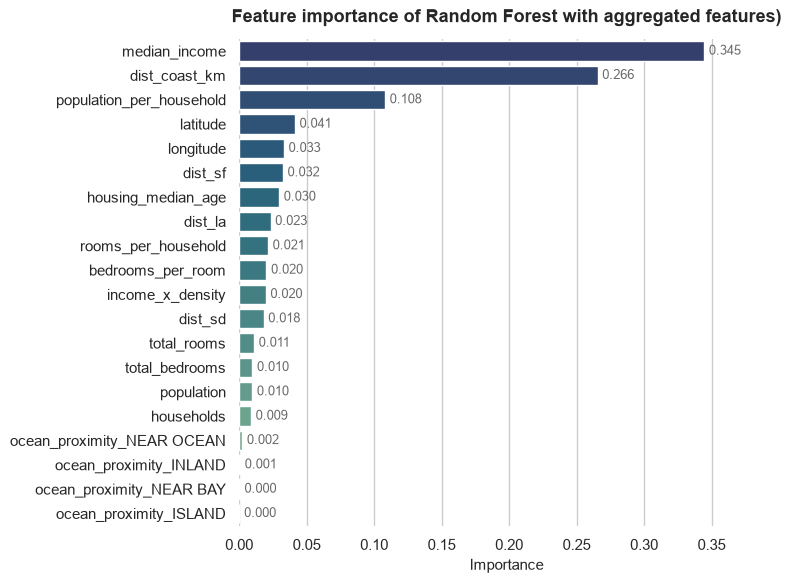

In [93]:
importances = rf_agg.feature_importances_
feature_names = X_train_agg.columns


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df)

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette("crest", n_colors=len(importance_df))[::-1]

# Plotting
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette=palette,
    legend=False,
    ax=ax
)

# annotate each bar with its value
for i, v in enumerate(importance_df["Importance"]):
    ax.text(v + importance_df["Importance"].max() * 0.01, i, f"{v:.3f}",
            va="center", fontsize=9, color="dimgray")

ax.set_xlabel("Importance", fontsize=11)
ax.set_ylabel("")
ax.set_title("Feature importance of Random Forest with aggregated features)", fontsize=13, weight="bold", pad=12)
ax.set_xlim(0, importance_df["Importance"].max() * 1.15)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("images/feature_importance_agg.png", dpi=300, bbox_inches="tight")
plt.show()

Notice that now the aggreated feauture like "dist_coast_km" contributes to the model in the second place.

## IVC. XGBoost

In [94]:
xgbr_agg = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)
xgbr_agg.fit(X_train_agg, y_train_agg)
y_pred_xgb_agg = xgbr_agg.predict(X_test_agg)
print("R2 score is", r2_score(y_test_agg, y_pred_xgb_agg))

R2 score is 0.8187434250799236


$R^2$ is imporved and becomes the best I can achive in this analysis. It is emphasised that XGBoost can capture well the non-linear feaures.

                       Feature  Importance
19               dist_coast_km    0.266880
7                median_income    0.258650
8       ocean_proximity_INLAND    0.084226
14    population_per_household    0.068816
9       ocean_proximity_ISLAND    0.039694
11  ocean_proximity_NEAR OCEAN    0.035956
16                     dist_sf    0.033833
1                     latitude    0.030441
18                     dist_sd    0.024116
17                     dist_la    0.023761
0                    longitude    0.021570
10    ocean_proximity_NEAR BAY    0.020099
2           housing_median_age    0.018884
12         rooms_per_household    0.013781
13           bedrooms_per_room    0.011471
6                   households    0.011185
15            income_x_density    0.010831
4               total_bedrooms    0.008952
5                   population    0.008533
3                  total_rooms    0.008319


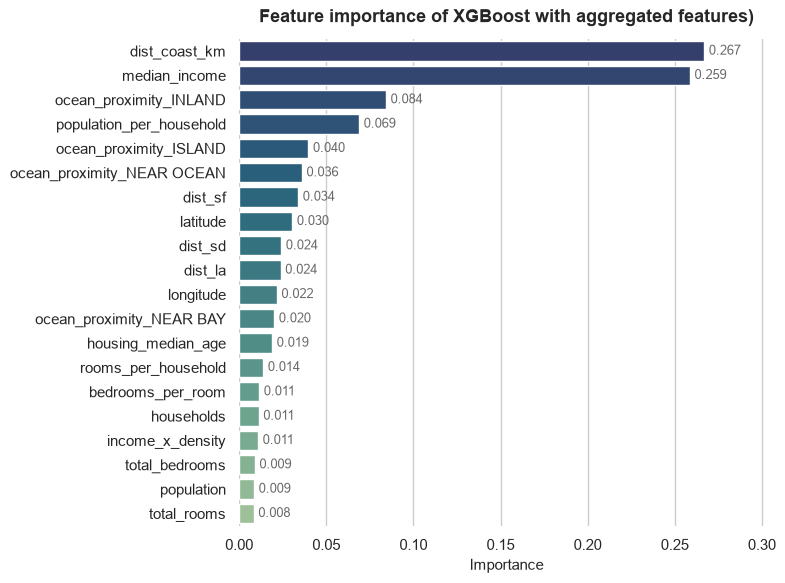

In [95]:
importances = xgbr_agg.feature_importances_
feature_names = X_train_agg.columns


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df)

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette("crest", n_colors=len(importance_df))[::-1]

# Plotting
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette=palette,
    legend=False,
    ax=ax
)

# annotate each bar with its value
for i, v in enumerate(importance_df["Importance"]):
    ax.text(v + importance_df["Importance"].max() * 0.01, i, f"{v:.3f}",
            va="center", fontsize=9, color="dimgray")

ax.set_xlabel("Importance", fontsize=11)
ax.set_ylabel("")
ax.set_title("Feature importance of XGBoost with aggregated features)", fontsize=13, weight="bold", pad=12)
ax.set_xlim(0, importance_df["Importance"].max() * 1.15)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("images/feature_importance_xgb_agg.png", dpi=300, bbox_inches="tight")
plt.show()

It is clear to me that the distance from the coast is really important in predicting the house price.

## IVD. Residule analysis (Aggregated features)

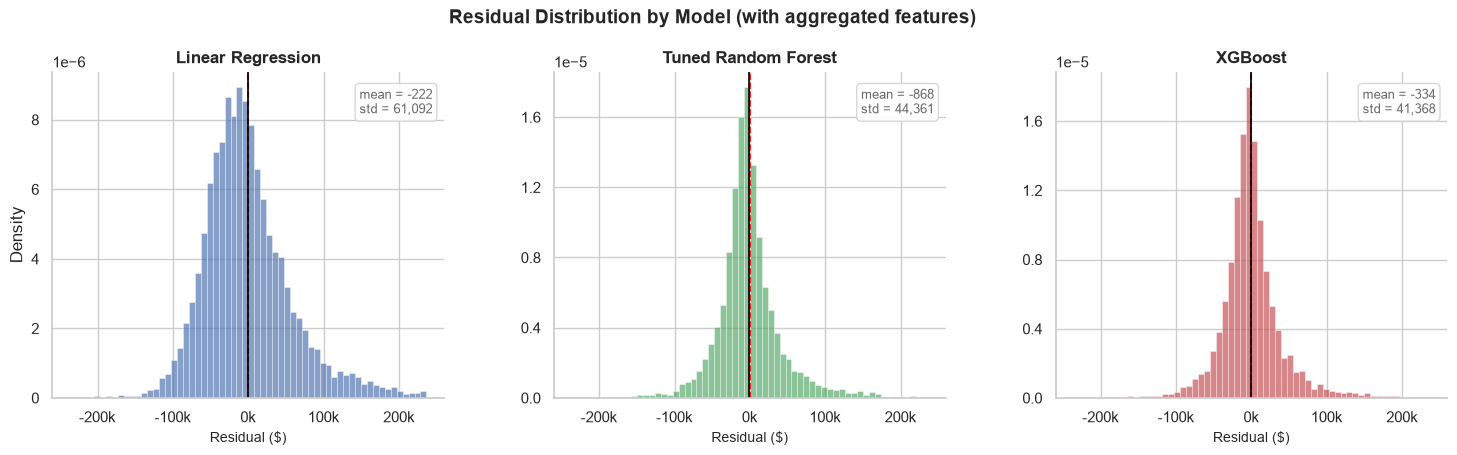

Mean residual (LR): -222.3
Std of residuals (LR): 61092.2
Mean residual (RF): -867.6
Std of residuals (RF): 44361.4
Mean residual (XG): -333.8
Std of residuals (XG): 41368.3


In [136]:
residuals_LR_agg = y_test_agg - y_pred_sgd_agg # Linear regression model
residuals_RF_agg = y_test_agg - y_pred_rf_agg # Tuned random forest model
residuals_XG_agg = y_test_agg - y_pred_xgb_agg # XGBoost

sns.set_theme(style="whitegrid", context="notebook")
os.makedirs("images", exist_ok=True)
plt.close("all")

datasets_raw = [
    (residuals_LR_agg, "Linear Regression", "#4C72B0"),
    (residuals_RF_agg, "Tuned Random Forest", "#55A868"),
    (residuals_XG_agg, "XGBoost", "#C44E52"),
]

datasets = []
for resid, label, color in datasets_raw:
    resid = np.asarray(resid, dtype="float64").ravel()
    resid = resid[np.isfinite(resid)]
    datasets.append((resid, label, color))

# Use a central range so the plot does not get crushed by extreme residuals
x_limit = max(np.percentile(np.abs(resid), 99.5) for resid, _, _ in datasets)
bins = np.linspace(-x_limit, x_limit, 61)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), sharey=False)

for i, (resid, label, color) in enumerate(datasets):
    plot_resid = resid[(resid >= -x_limit) & (resid <= x_limit)]

    ax[i].hist(
        plot_resid,
        bins=bins,
        density=True,
        color=color,
        alpha=0.68,
        edgecolor="white",
        linewidth=0.4
    )

    mean_r = resid.mean()
    std_r = resid.std()

    ax[i].axvline(0, color="red", linestyle="--", linewidth=1.2)
    ax[i].axvline(mean_r, color="black", linestyle="-", linewidth=1.2)

    ax[i].set_title(label, fontsize=12, weight="bold")
    ax[i].set_xlabel("Residual ($)", fontsize=10)
    ax[i].set_ylabel("Density" if i == 0 else "")

    ax[i].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")
    )
    ax[i].yaxis.set_major_locator(mticker.MaxNLocator(5))

    stats_text = (
        f"mean = {mean_r:,.0f}\n"
        f"std = {std_r:,.0f}"
    )

    ax[i].text(
        0.97,
        0.95,
        stats_text,
        transform=ax[i].transAxes,
        ha="right",
        va="top",
        fontsize=9,
        color="dimgray",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.9
        )
    )

    sns.despine(ax=ax[i])

fig.suptitle("Residual Distribution by Model (with aggregated features)", fontsize=14, weight="bold", y=0.97)
fig.subplots_adjust(left=0.06, right=0.99, bottom=0.16, top=0.84, wspace=0.28)

fig.savefig("images/residual_distribution_agg.png", dpi=300)
plt.show()

for name, resid in [("LR", residuals_LR_agg), ("RF", residuals_RF_agg), ("XG", residuals_XG_agg)]:
    resid = np.asarray(resid, dtype="float64").ravel()
    resid = resid[np.isfinite(resid)]

    print(f"Mean residual ({name}): {resid.mean():.1f}")
    print(f"Std of residuals ({name}): {resid.std():.1f}")

It is interesting to see that all models' mean residuals are increased despite their improvments of $R^2$. However, it is important to see that all the standard deviations are decreased. This reflects more reliable models with smaller uncertainties.  The XGBoost model remains the best model with smallest mean residual of -$527. 

# V. Conclusion and Discussion

In this analysis, three models were built and compared: Linear Regression, Random Forest, and XGBoost, to predict median house prices in California. The data was first cleaned by filtering out extreme values near the $500,000 cap, a known artefact in this dataset, and filling missing values in `total_bedrooms` with the column median.

Linear Regression achieved an $R^2$ score of 60.4%, which serves as a reasonable baseline. Adding aggregated features such as rooms per household and population per household did not improve this score meaningfully, as the underlying relationships between features and house price are non-linear, which a linear model cannot learn regardless of the features provided. Switching to Random Forest and XGBoost raised $R^2$ significantly to 78.4% and 80.2% respectively, as these models can capture non-linear relationships naturally. Adding geographical features such as distances to the nearest coastline and major cities pushed XGBoost further to 82.0%, confirming that location encodes price signals that latitude and longitude alone do not fully capture for any of the three models.

Residual analysis revealed that all three models produce residuals centred around zero with a roughly normal distribution, which is a healthy sign. However, plotting absolute errors geographically showed that the worst predictions are concentrated around major cities and coastal areas, where prices are more volatile and harder to predict from the available features alone. This finding directly motivated the addition of the distance features.

Looking inside the models via feature importance, median income remains the strongest single predictor by a significant margin, while geographical features collectively play a crucial supporting role. This is intuitive: neighbourhood and proximity to economic centres strongly shape property values.

One important trade-off emerged from the residual analysis. Although adding aggregated features improved $R^2$ (i.e., reduced the standard deviation of errors), the mean errors increased slightly across all models. **This reflects a trade-off between bias and variance: a model can be more reliable on average while being slightly less accurate in expectation.** Which side of this trade-off to favour is ultimately a business decision, depending on whether minimising the worst-case errors or minimising average prediction error matters more for the use case. For example, the XGBoost model with engineered features produces a mean error of -\\$333.8, slightly higher in magnitude than the -\\$216.8 mean error without engineered features, but yields a lower standard deviation of \\$41,368.3, roughly \\$2,000 lower than the model without aggregation.